In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from wordcloud import WordCloud

plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "spam_clean.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   label       5572 non-null   str  
 1   message     5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 5572
Columns: 5


In [5]:
print(df.isnull().sum())

label            0
message          0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [6]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 403


In [7]:
df = df.drop_duplicates().reset_index(drop=True)

print("New Shape:", df.shape)

New Shape: (5169, 5)


In [8]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

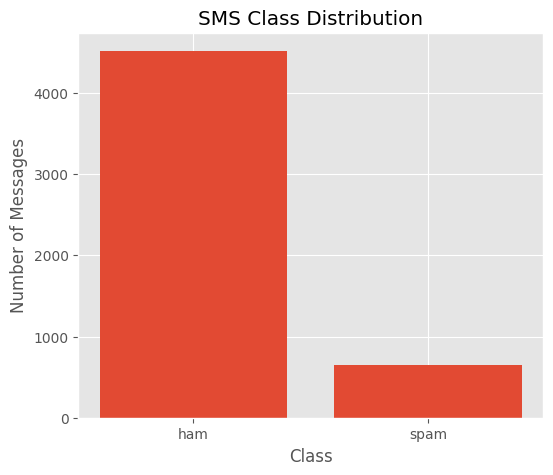

In [9]:
counts = df["label"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(counts.index, counts.values)

plt.title("SMS Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Messages")

plt.show()

In [10]:
round(df["label"].value_counts(normalize=True) * 100, 2)

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64

In [11]:
df["message_length"] = df["message"].astype(str).apply(len)

df.head()

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61


In [12]:
df["message_length"].describe()

count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: message_length, dtype: float64

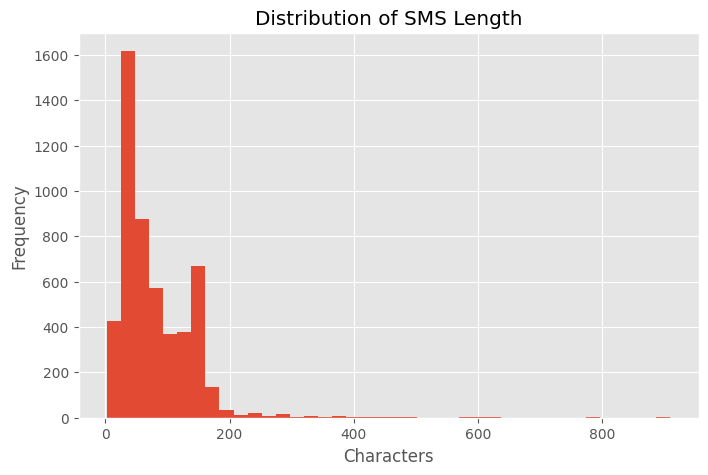

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["message_length"], bins=40)

plt.title("Distribution of SMS Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

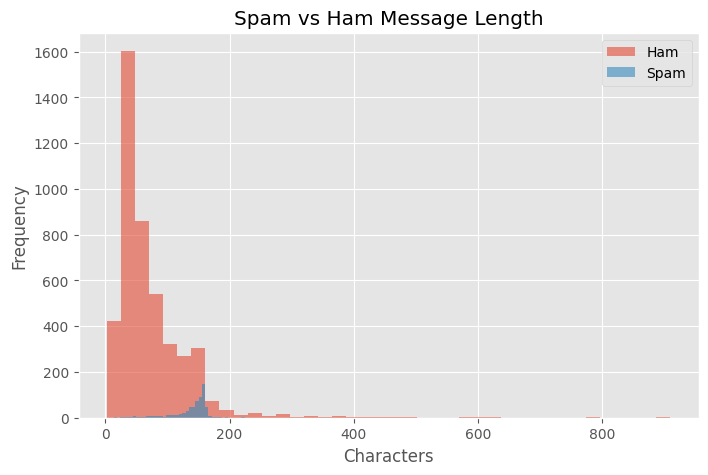

In [14]:
spam = df[df["label"] == "spam"]["message_length"]
ham = df[df["label"] == "ham"]["message_length"]

plt.figure(figsize=(8,5))

plt.hist(ham, bins=40, alpha=0.6, label="Ham")
plt.hist(spam, bins=40, alpha=0.6, label="Spam")

plt.legend()

plt.title("Spam vs Ham Message Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [15]:
df.groupby("label")["message_length"].mean()

label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64

In [16]:
df["word_count"] = df["message"].astype(str).apply(lambda x: len(x.split()))

df.head()

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,20
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,28
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,13


In [17]:
df["word_count"] = df["message"].astype(str).apply(lambda x: len(x.split()))

df.head()

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,20
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,28
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,13


In [18]:
df.loc[df["message_length"].idxmax()]

label                                                           ham
message           For me the love should start with attraction.i...
Unnamed: 2                                                      NaN
Unnamed: 3                                                      NaN
Unnamed: 4                                                      NaN
message_length                                                  910
word_count                                                      171
Name: 1059, dtype: object

In [19]:
df.loc[df["message_length"].idxmin()]

label             ham
message            Ok
Unnamed: 2        NaN
Unnamed: 3        NaN
Unnamed: 4        NaN
message_length      2
word_count          1
Name: 1858, dtype: object

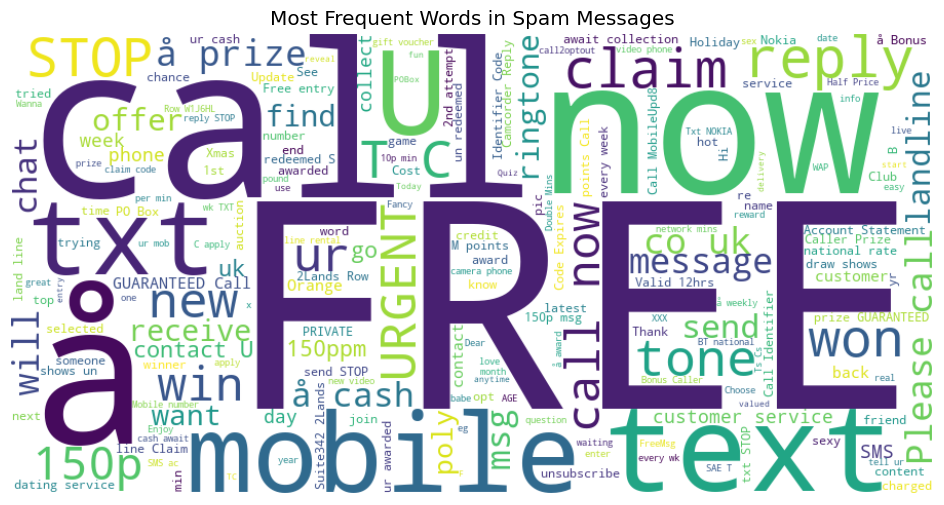

In [20]:
spam_text = " ".join(
    df[df["label"] == "spam"]["message"].astype(str)
)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    random_state=42
).generate(spam_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Spam Messages")
plt.show()

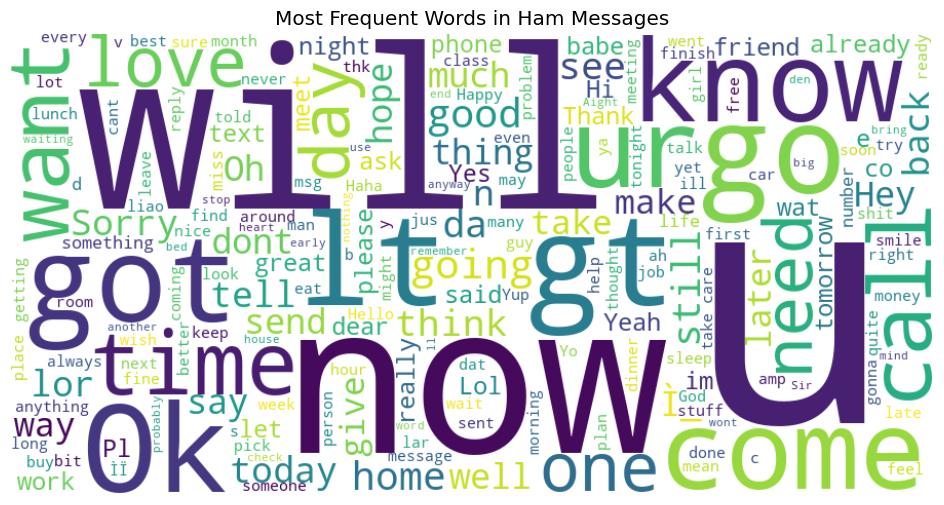

In [21]:
ham_text = " ".join(
    df[df["label"] == "ham"]["message"].astype(str)
)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    random_state=42
).generate(ham_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Ham Messages")
plt.show()

In [22]:
df.nlargest(10, "message_length")[["label", "message_length", "message"]]

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


,label,message_length,message
1059,ham,910,For me the love should start with attraction.i...
1800,ham,790,The last thing i ever wanted to do was hurt yo...
2333,ham,632,Indians r poor but India is not a poor country...
1528,ham,611,How to Make a girl Happy? It's not at all diff...
2075,ham,588,Sad story of a Man - Last week was my b'day. M...
2281,ham,482,"Good evening Sir, hope you are having a nice d..."
2863,ham,461,"&lt;#&gt; is fast approaching. So, Wish u a v..."
1463,ham,458,"Hey sweet, I was wondering when you had a mome..."
2271,ham,450,A Boy loved a gal. He propsd bt she didnt mind...
2308,ham,444,Solve d Case : A Man Was Found Murdered On &l...


In [23]:
OUTPUT_PATH = PROJECT_ROOT / "data" / "spam_eda.csv"

df.to_csv(OUTPUT_PATH, index=False)

print(f"EDA dataset saved to:\n{OUTPUT_PATH}")

EDA dataset saved to:
c:\Users\dan2s\OneDrive\Documents\ONE\Desktop\Fraud_SMS_Classifier\data\spam_eda.csv


In [24]:
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 60)

print(f"Total Messages       : {len(df)}")
print(f"Ham Messages         : {(df['label']=='ham').sum()}")
print(f"Spam Messages        : {(df['label']=='spam').sum()}")

print(f"\nAverage Length       : {df['message_length'].mean():.2f} characters")
print(f"Average Word Count   : {df['word_count'].mean():.2f}")

print(f"\nLongest SMS          : {df['message_length'].max()} characters")
print(f"Shortest SMS         : {df['message_length'].min()} characters")

print("=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)

EXPLORATORY DATA ANALYSIS SUMMARY
Total Messages       : 5169
Ham Messages         : 4516
Spam Messages        : 653

Average Length       : 78.98 characters
Average Word Count   : 15.34

Longest SMS          : 910 characters
Shortest SMS         : 2 characters
EDA COMPLETED SUCCESSFULLY
